# **XGBoost and grid search on diabetes.csv**

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score

In [140]:
df=pd.read_csv("diabetes.csv")

In [141]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [142]:
df.shape

(768, 9)

In [143]:
df=df.drop(columns=["Pregnancies","SkinThickness","BMI"])
df.head()

,Glucose,BloodPressure,Insulin,DiabetesPedigreeFunction,Age,Outcome
0,148,72,0,0.627,50,1
1,85,66,0,0.351,31,0
2,183,64,0,0.672,32,1
3,89,66,94,0.167,21,0
4,137,40,168,2.288,33,1


In [144]:
#the data for XGB
df_XGB=df

In [145]:
#xgbbost can handle missing values but stll
missing_rows = df_GB.isnull().any(axis=1).sum()
print(f"Rows with missing values: {missing_rows}")
#no empty rows



Rows with missing values: 0


In [146]:
X_train, X_test, y_train, y_test = train_test_split(df_XGB.drop(columns=['Outcome']), df_XGB['Outcome'], test_size=.2)


# **XGBoost hyperparameter tuning in Python using grid search**

https://mikulskibartosz.name/xgboost-hyperparameter-tuning-in-python-using-grid-search

In [147]:
from sklearn.model_selection import GridSearchCV

In [148]:
estimator = XGBClassifier(
    objective= 'binary:logistic',
    verbosity=1
)

In [149]:
parameters = {
    'max_depth': range (2, 10, 1),
    'n_estimators': range(60, 220, 40),
    'learning_rate': [0.1, 0.01, 0.05]
}

In [150]:
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=parameters,
    scoring='accuracy',
    cv=10,
    verbose=1
)

In [151]:
# fit model
grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 96 candidates, totalling 960 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': range(2, 10),
                         'n_estimators': range(60, 220, 40)},
             scoring='accuracy', verbose=1)

In [152]:
print("The best hyperparameters are : ","\n")
print("Max Depth:", grid_search.best_estimator_.max_depth)
print("Number of Estimators:", grid_search.best_estimator_.n_estimators)
print("Learning Rate:", grid_search.best_estimator_.learning_rate)

The best hyperparameters are :  

Max Depth: 3
Number of Estimators: 60
Learning Rate: 0.1


# **Evaluation**


In [153]:
best_model = XGBClassifier(n_estimators=grid_search.best_estimator_.n_estimators, max_depth=grid_search.best_estimator_.max_depth, learning_rate=grid_search.best_estimator_.learning_rate, objective='binary:logistic')

In [154]:
best_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=True)

[0]	validation_0-logloss:0.61278	validation_1-logloss:0.63940
[1]	validation_0-logloss:0.58706	validation_1-logloss:0.62415
[2]	validation_0-logloss:0.56532	validation_1-logloss:0.61315
[3]	validation_0-logloss:0.54728	validation_1-logloss:0.60374
[4]	validation_0-logloss:0.53162	validation_1-logloss:0.59771
[5]	validation_0-logloss:0.51824	validation_1-logloss:0.59145
[6]	validation_0-logloss:0.50644	validation_1-logloss:0.58556
[7]	validation_0-logloss:0.49568	validation_1-logloss:0.57884
[8]	validation_0-logloss:0.48603	validation_1-logloss:0.57498
[9]	validation_0-logloss:0.47759	validation_1-logloss:0.56984
[10]	validation_0-logloss:0.47030	validation_1-logloss:0.56486
[11]	validation_0-logloss:0.46332	validation_1-logloss:0.56588
[12]	validation_0-logloss:0.45729	validation_1-logloss:0.56158
[13]	validation_0-logloss:0.45205	validation_1-logloss:0.55771
[14]	validation_0-logloss:0.44702	validation_1-logloss:0.55954
[15]	validation_0-logloss:0.44219	validation_1-logloss:0.55893
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=60, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [155]:
evals = best_model.evals_result()

In [156]:
train_logloss =evals["validation_0"]["logloss"]
test_logloss = evals["validation_1"]["logloss"]

In [157]:
final_train_logloss = evals["validation_0"]["logloss"][-1]
final_test_logloss = evals["validation_1"]["logloss"][-1]
print("Final Train Log-Loss:", final_train_logloss)
print("Final Test Log-Loss:", final_test_logloss)

Final Train Log-Loss: 0.3515640084892633
Final Test Log-Loss: 0.5801389252936299


In [158]:
test_preds =best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)*100
train_preds = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_preds) * 100

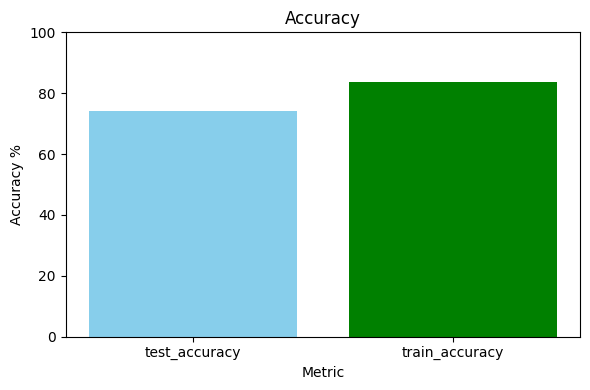

In [159]:
# Data


# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(['test_accuracy'], test_accuracy, color='skyblue')
plt.bar(['train_accuracy'], train_accuracy, color='green')
plt.ylim(0, 100)  # Accuracy range: 0 to 1
plt.title('Accuracy')
plt.xlabel('Metric')
plt.ylabel('Accuracy %')

# Display plot
plt.tight_layout()
plt.show()

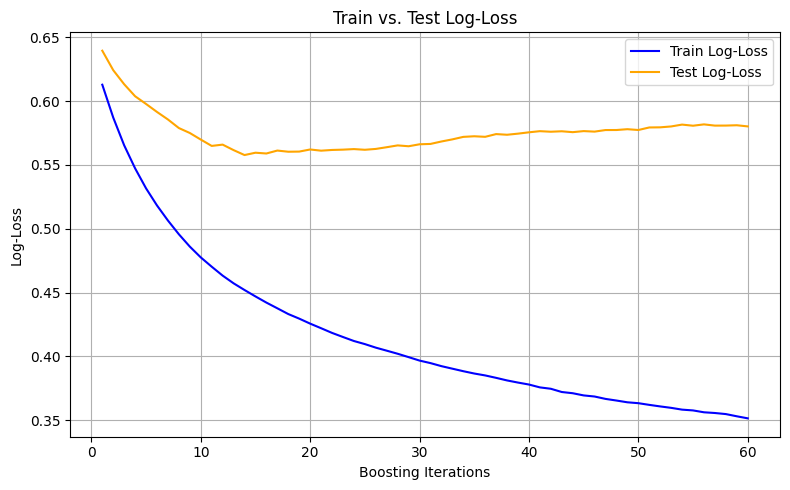

In [160]:
# Data
iterations = range(1, len(train_logloss) + 1)

# Create line plot
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_logloss, label='Train Log-Loss', color='blue')
plt.plot(iterations, test_logloss, label='Test Log-Loss', color='orange')
plt.title('Train vs. Test Log-Loss')
plt.xlabel('Boosting Iterations')
plt.ylabel('Log-Loss')
plt.legend()
plt.grid(True)

# Display plot
plt.tight_layout()
plt.show()